# LOWESS/Spline Smoothing Data Application and Analysis Project

Dataset: [Bike Sharing Dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset)

Goal: Apply LOWESS and Spline smoothing to this dataset, and analyze their impact on understanding the raw data, and compare their outcomes to each other.

### 1. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import UnivariateSpline

### 2. Load Dataset

In [17]:
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('hour.csv')

df = df[['hr','cnt']]
df.dropna(inplace=True)
df

,hr,cnt
0,0,16
1,1,40
2,2,32
3,3,13
4,4,1
...,...,...
17374,19,119
17375,20,89
17376,21,90
17377,22,61


### 3. Raw Data Visualization
Visualizing Hour vs Number of Bike Rentals

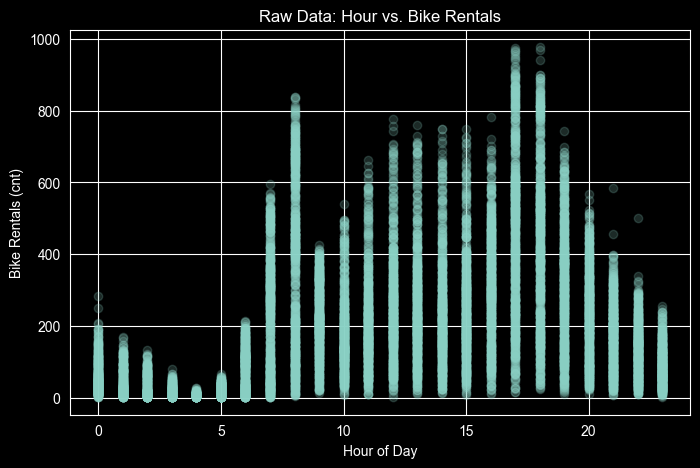

In [18]:
plt.scatter(df['hr'],df['cnt'], alpha=0.2)
plt.xlabel('Hour of Day')
plt.ylabel('Bike Rentals (cnt)')
plt.title('Raw Data: Hour vs. Bike Rentals')
plt.show()


### 4. LOWESS Smoothing
Applying LOWESS smoothing to the Hour vs. Bike Rentals data.

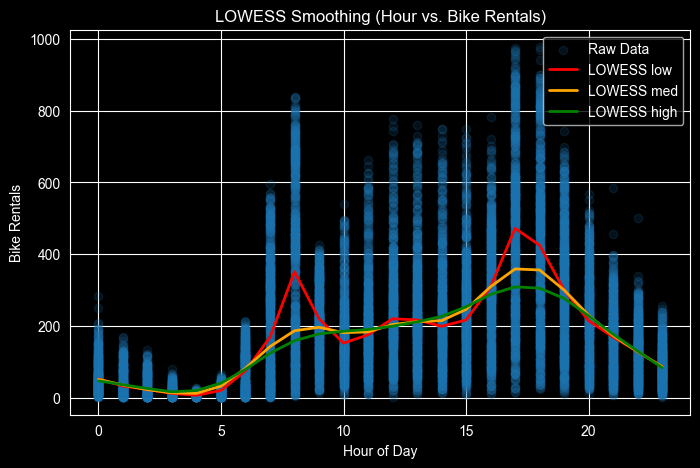

In [19]:
#showcasing frac factor
lowess_hr_low = lowess(df['cnt'], df['hr'], frac=0.05)
lowess_hr_med = lowess(df['cnt'], df['hr'], frac=0.15)
lowess_hr_high = lowess(df['cnt'], df['hr'], frac=0.25)

#plot scatter
plt.scatter(df['hr'],df['cnt'], alpha=0.15, color='tab:blue', label='Raw Data')

#plot lowess output
plt.plot(lowess_hr_low[:,0],lowess_hr_low[:,1], color='red', linewidth=2, label='LOWESS low')
plt.plot(lowess_hr_med[:,0],lowess_hr_med[:,1], color='orange', linewidth=2, label='LOWESS med')
plt.plot(lowess_hr_high[:,0],lowess_hr_high[:,1], color='green', linewidth=2, label='LOWESS high')

plt.xlabel('Hour of Day')
plt.ylabel('Bike Rentals')
plt.title('LOWESS Smoothing (Hour vs. Bike Rentals)')
plt.legend()
plt.show()

### 5. Spline Smoothing
Spline Smoothing for Hour vs. Num Bike Rentals

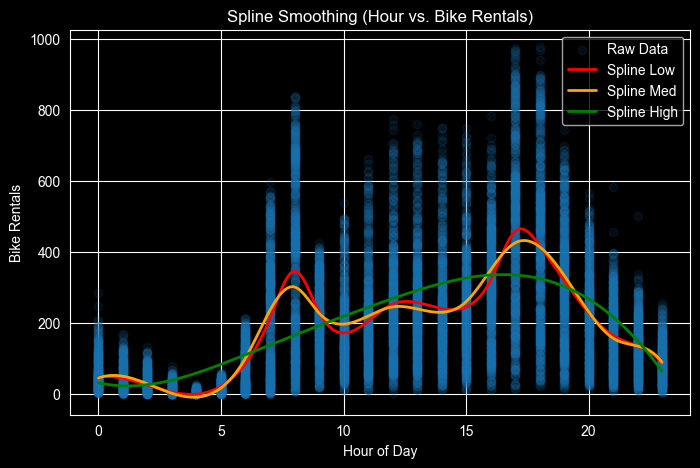

In [24]:
# aggregate data for spline
df_grouped = df.groupby('hr')['cnt'].mean().reset_index()

x = df_grouped['hr']
y = df_grouped['cnt']

# fit spline
from scipy.interpolate import UnivariateSpline
spline_low = UnivariateSpline(x, y, s=1000)
spline_med = UnivariateSpline(x, y, s=10000)
spline_high = UnivariateSpline(x, y, s=100000)

# generate curve
x_range = np.linspace(x.min(), x.max(), 1000)
y_spline_low = spline_low(x_range)
y_spline_med = spline_med(x_range)
y_spline_high = spline_high(x_range)

# plot
plt.scatter(df['hr'], df['cnt'], alpha=0.1, color='tab:blue', label='Raw Data')
plt.plot(x_range, y_spline_low, color='red', linewidth=2, label='Spline Low')
plt.plot(x_range, y_spline_med, color='orange', linewidth=2, label='Spline Med')
plt.plot(x_range, y_spline_high, color='green', linewidth=2, label='Spline High')

plt.xlabel('Hour of Day')
plt.ylabel('Bike Rentals')
plt.title('Spline Smoothing (Hour vs. Bike Rentals)')
plt.legend()
plt.show()

### 6. Direct Comparison
Spline vs. LOWESS

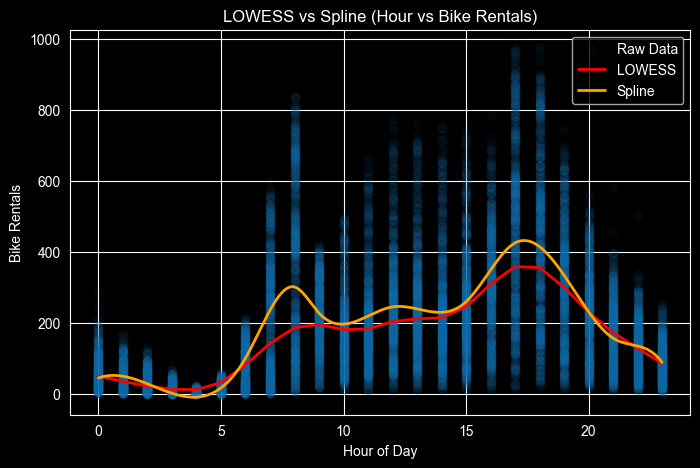

In [21]:
plt.scatter(df['hr'], df['cnt'], alpha=0.05, color='tab:blue', label='Raw Data')

plt.plot(lowess_hr_med[:, 0], lowess_hr_med[:, 1],
         color='red', linewidth=2, label='LOWESS')

plt.plot(x_range, y_spline_med,
         color='orange', linewidth=2, label='Spline')

plt.xlabel('Hour of Day')
plt.ylabel('Bike Rentals')
plt.title('LOWESS vs Spline (Hour vs Bike Rentals)')
plt.legend()
plt.show()

### 7. Key Takeaways
| LOWESS | Spline                                                                                                                                                                                                                           |
| -------- |----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| LOWESS smoothing is flatter than Spline smoothing | Spline smoothing is much more sensitive than LOWESS smoothing, and can require some tuning with the smoothing parameter to avoid overrepresenting outliers                                                                       |
| LOWESS smoothing captures the overall trend of the data, identifying peak hours are 16-19, and not being as vulnerable to the 8am spike | Spline smoothing captures local trends better, identifying the 8am bike rental spike, the 12-14 bump in bike usage, and the peak hours of 16-19                                                                                  |
| LOWESS would mostly be used to identify broader trends in bike usage throughout the hours of the day. Good for stakeholders and researchers doing Exploratory Data Analysis (EDA) | Spline smoothing would mostly be used for making predictions and building models. Spline smoothing preserves more accurate data on the hour-by-hour level, and can help a planner identify how many bikes would be in use at 2:30 |
